Matplotlib is building the font cache; this may take a moment.


Loaded Impact_of_Mobile_Phone_on_Students_Health.csv: (100, 20)
Loaded med dataset.csv: (886, 20)
Loaded mentalhealth_dataset.csv: (1000, 16)
Loaded mental_health_dataset.csv: (500, 13)
Loaded ScreenTime vs MentalWellness.csv: (400, 16)
Loaded Social_media_impact_on_life (1).csv: (1705, 11)
Loaded Social_media_impact_on_life.csv: (1705, 11)
Loaded Student Mental Health Analysis During Online Learning.csv: (1000, 10)
Loaded Students Social Media Addiction.csv: (705, 13)
Loaded student_depression_dataset.csv: (27901, 18)
Loaded student_mental_health_burnout.csv: (150000, 20)
Loaded student_mental_health_burnout_1M.csv: (1000000, 20)
Loaded student_mental_health_dataset.csv: (1000, 10)
Loaded Student_Mental_Stress_and_Coping_Mechanisms.csv: (760, 20)
Standardised Impact_of_Mobile_Phone_on_Students_Health.csv: (100, 3)
Standardised med dataset.csv: (886, 4)
Standardised mentalhealth_dataset.csv: (1000, 7)
Standardised mental_health_dataset.csv: (500, 6)
Standardised ScreenTime vs MentalWel

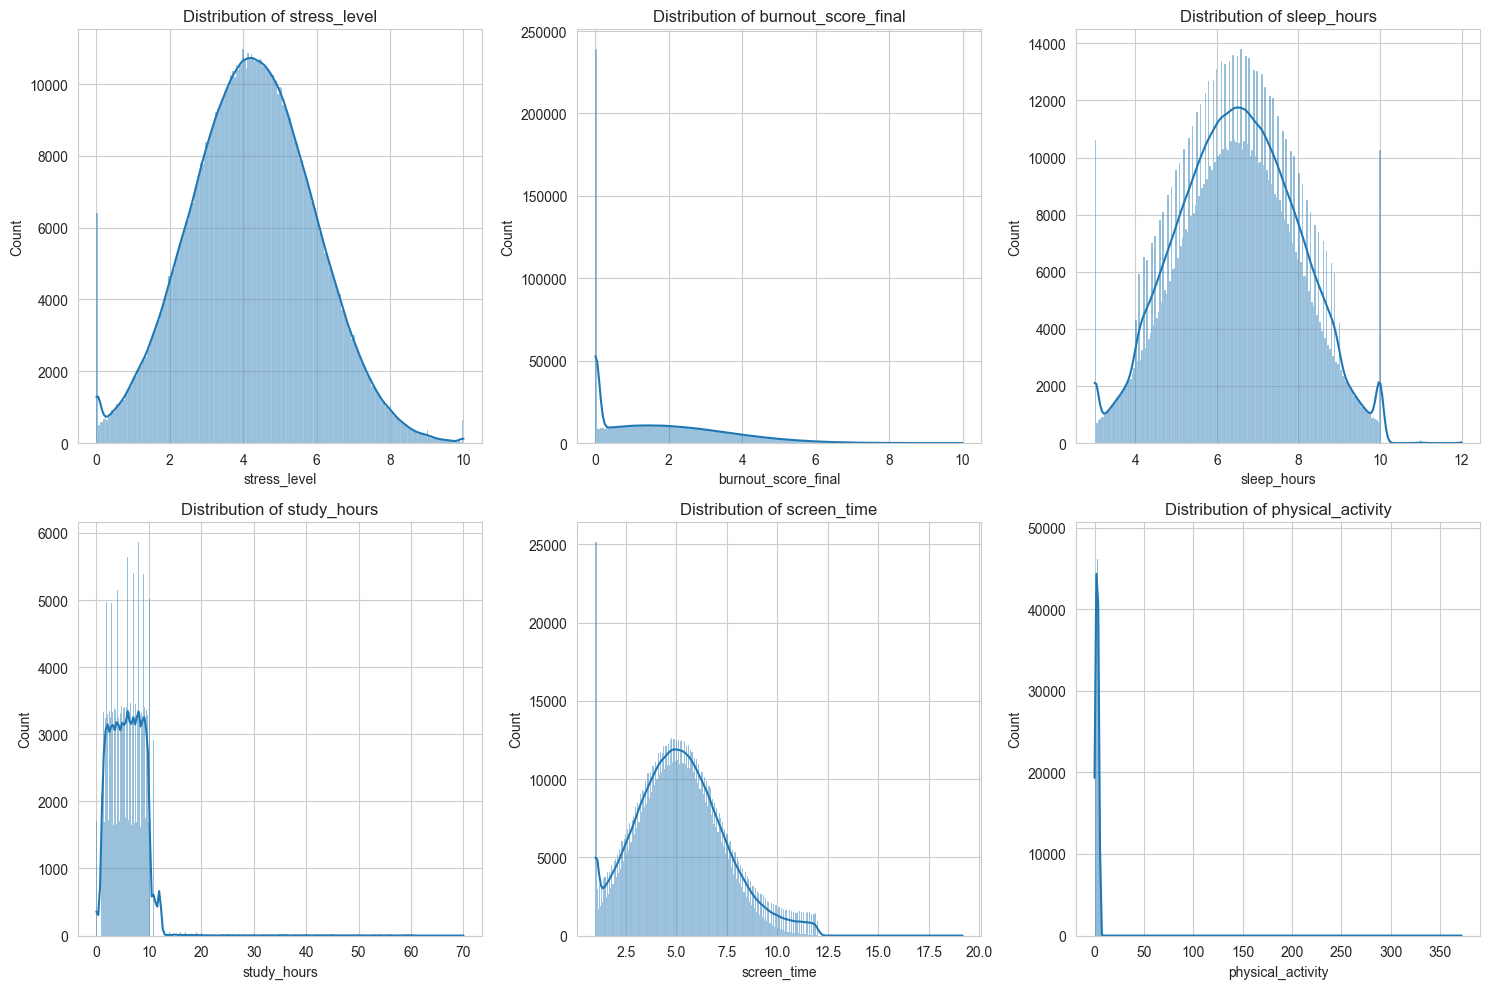

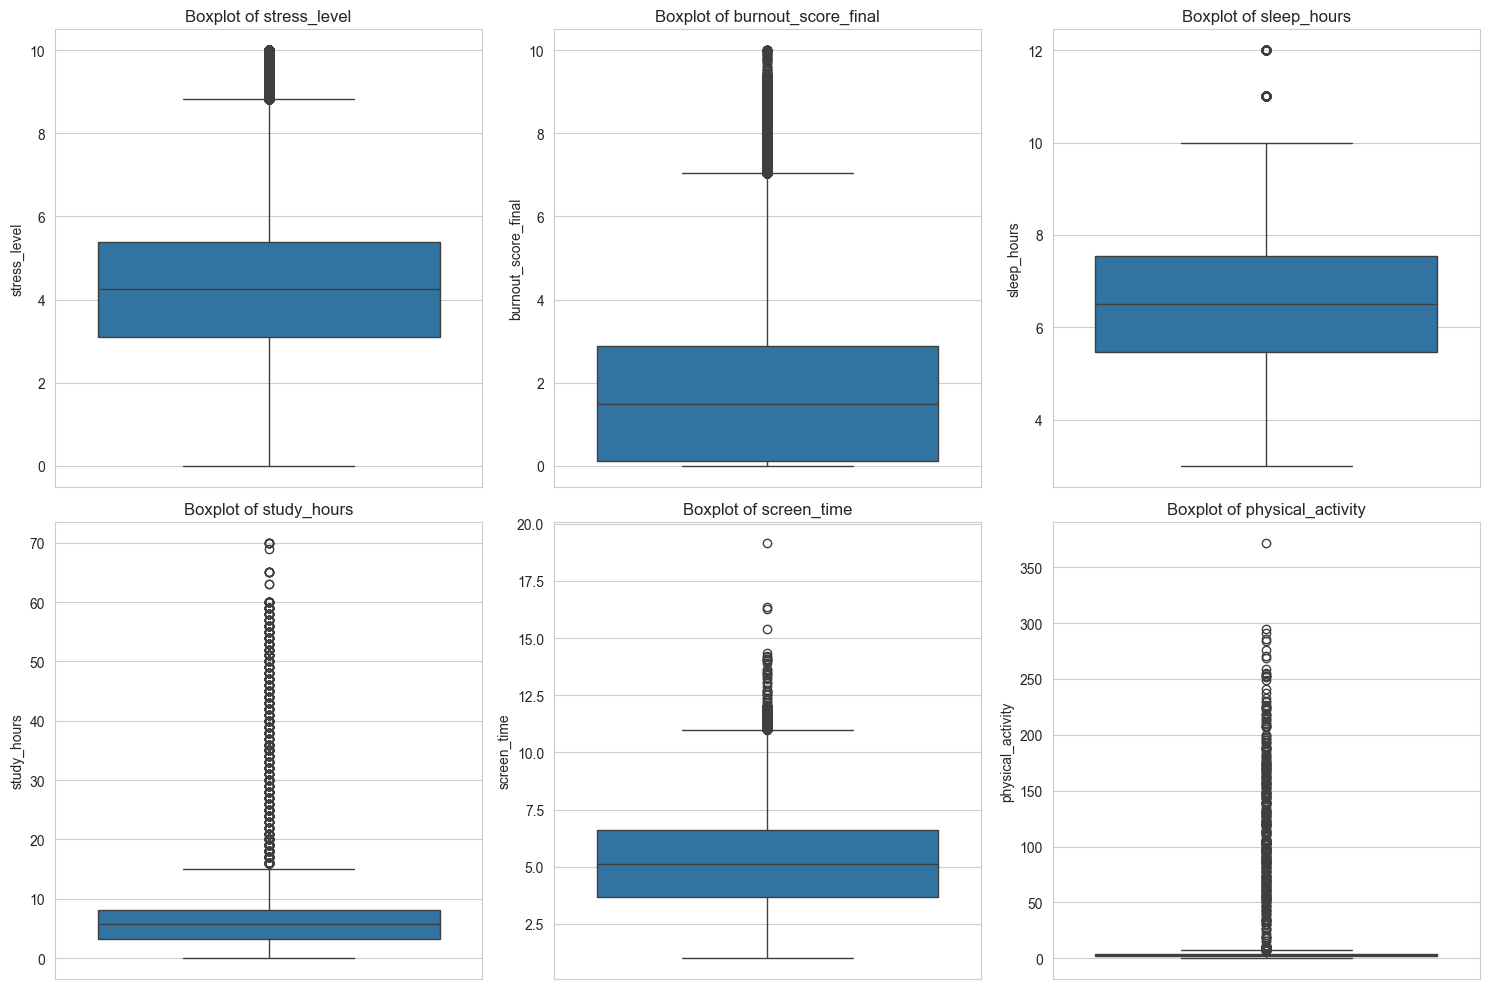

Shapiro-Wilk test for Stress Level: statistic=0.9985, p-value=0.0001
Stress level is NOT normally distributed (reject H0).


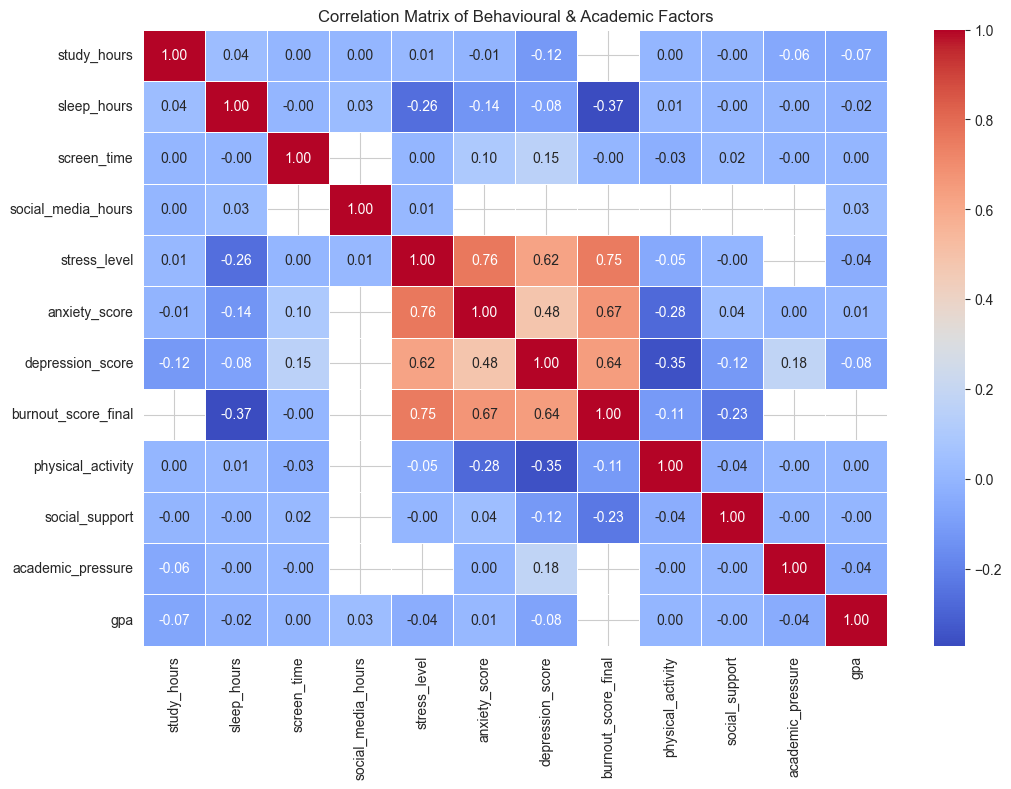

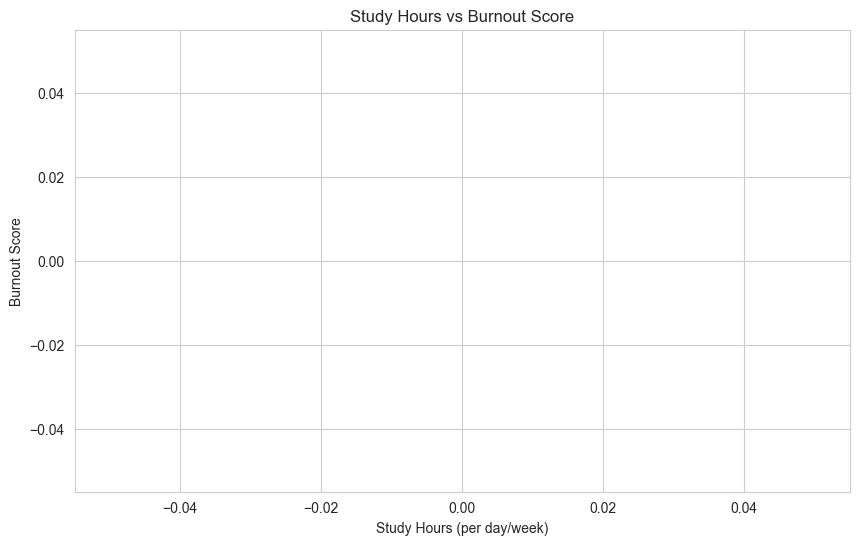

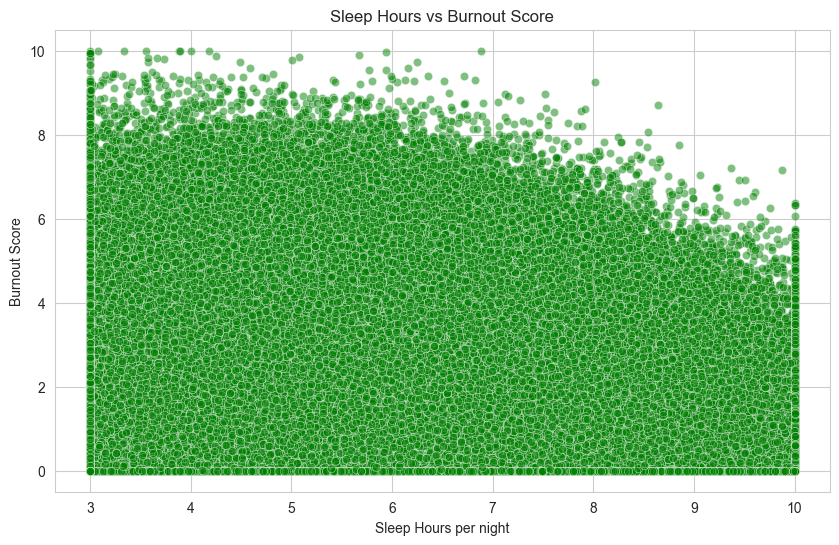

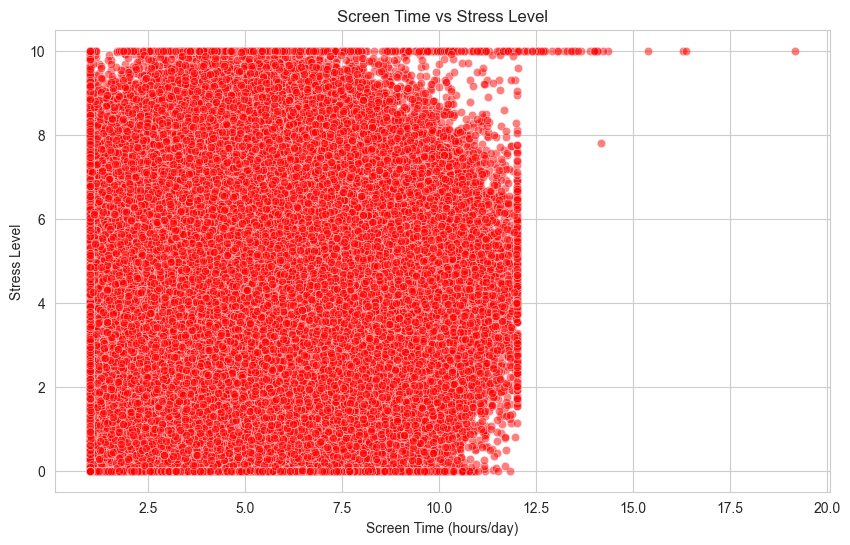

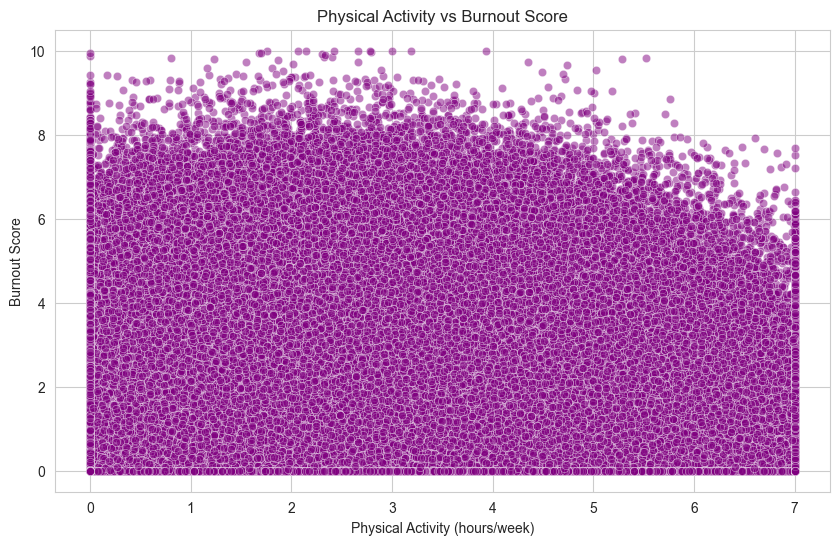

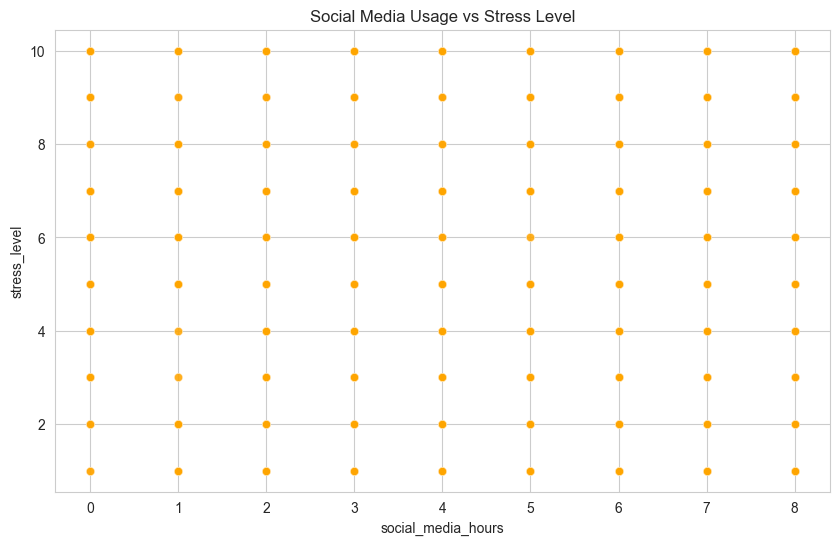

No complete rows for pairplot after dropping missing values.
=== T-Test: Sleep Duration vs Burnout ===
High sleep group (>=7h): n=370230, mean burnout=1.162
Low sleep group (<6h): n=368883, mean burnout=2.443
T-statistic = -350.3080, p-value = 0.000000
Reject H0: Sleep duration significantly impacts burnout.

=== ANOVA: Study Hours Categories vs Burnout ===
F-statistic = nan, p-value = nan
No significant difference among study hour groups.
=== Behavioural Segments ===
                          count      mean       std
segment                                            
Balanced Lifestyle       358157  0.990785  1.135785
High Stress / Low Sleep   89180  4.109437  1.472961
Other                    552663  1.922939  1.588887


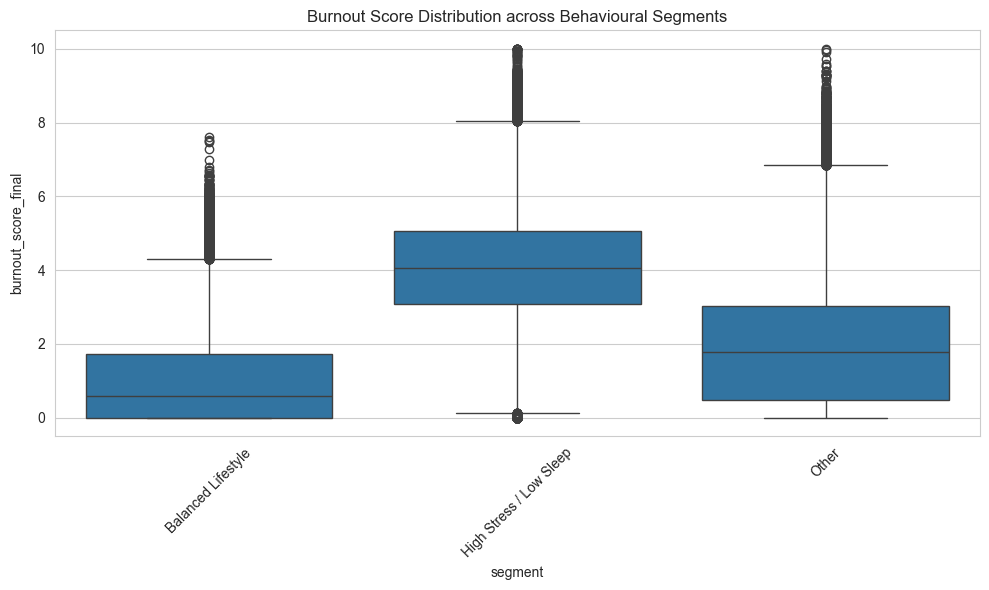

No complete rows for clustering after dropping missing values. Skipping KMeans.
Saved descriptive_stats.csv and segment_summary.csv
Clustering was not performed (no complete rows). Skipping cluster_personas.csv export.

Reports saved to ../reports/


In [1]:
# %% [markdown]
# # Student Burnout Statistical Study
# **AI & ML Internship – Task 2**
# 
# ### Objective
# Analyse student lifestyle and academic behaviour data to identify factors contributing to burnout.
# Use statistical techniques, visualisations, and machine learning clustering to uncover hidden patterns
# and propose actionable recommendations.
# 
# ### Datasets
# 13 CSV files with columns as described. All files are read from `../data/`.  
# Common features are standardised and merged into a single master dataframe.

# %% [code]
# ============================
# 1. IMPORTS & CONFIGURATION
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, f_oneway, chi2_contingency
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Paths (adjust if needed)
DATA_PATH = "../data/"
IMAGE_PATH = "../images/"
os.makedirs(IMAGE_PATH, exist_ok=True)          # create images folder if missing

# %% [code]
# ============================
# 2. LOAD ALL DATASETS
# ============================
file_names = [
    "Impact_of_Mobile_Phone_on_Students_Health.csv",
    "med dataset.csv",
    "mentalhealth_dataset.csv",
    "mental_health_dataset.csv",
    "ScreenTime vs MentalWellness.csv",
    "Social_media_impact_on_life (1).csv",
    "Social_media_impact_on_life.csv",
    "Student Mental Health Analysis During Online Learning.csv",
    "Students Social Media Addiction.csv",
    "student_depression_dataset.csv",
    "student_mental_health_burnout.csv",
    "student_mental_health_burnout_1M.csv",
    "student_mental_health_dataset.csv",
    "Student_Mental_Stress_and_Coping_Mechanisms.csv"
]

datasets = {}
for f in file_names:
    try:
        df = pd.read_csv(DATA_PATH + f)
        datasets[f] = df
        print(f"Loaded {f}: {df.shape}")
    except Exception as e:
        print(f"Error loading {f}: {e}")

# %% [markdown]
# ## 3. Column Standardisation & Feature Extraction
# 
# We define a mapping that renames similar columns to a common name.  
# Then we extract only the columns relevant to our analysis.

# %% [code]
# Common name mapping (original column patterns -> standard name)
rename_map = {
    # Demographics
    'Age': 'age', 'age': 'age',
    'Gender': 'gender', 'gender': 'gender', 'sex': 'gender',
    # Academic
    'Study Hours': 'study_hours', 'StudyHoursPerWeek': 'study_hours', 'daily_study_hours': 'study_hours',
    'stud_h': 'study_hours', 'Study Hours Per Week': 'study_hours',
    'GPA': 'gpa', 'CGPA': 'gpa', 'Academic Performance (GPA)': 'gpa',
    'Academic Pressure': 'academic_pressure', 'academic_pressure_score': 'academic_pressure',
    # Sleep
    'Sleep Hours': 'sleep_hours', 'Sleep Hours Per Night': 'sleep_hours', 'Sleep Duration (hrs)': 'sleep_hours',
    'Sleep Duration': 'sleep_hours', 'daily_sleep_hours': 'sleep_hours',
    'Sleep Quality': 'sleep_quality',
    # Screen time / social media
    'Screen Time (hrs/day)': 'screen_time', 'screen_time_hours': 'screen_time', 'Avg_Daily_Usage_Hours': 'screen_time',
    'Social Media Usage (Hours per day)': 'social_media_hours',
    # Mental health
    'Stress Level': 'stress_level', 'stress_level_0_10': 'stress_level', 'Mental Stress Level': 'stress_level',
    'Anxiety Score': 'anxiety_score', 'anxiety': 'anxiety_score',
    'Depression Score': 'depression_score', 'depression': 'depression_score',
    'Burnout Score': 'burnout_score', 'burnout_score': 'burnout_score', 'burnout_level': 'burnout_score',
    # Lifestyle
    'Physical Activity (hrs/week)': 'physical_activity', 'physical_activity_hours': 'physical_activity',
    'Exercise minutes per week': 'physical_activity', 'exercise_minutes_per_week': 'physical_activity',
    'Diet Quality': 'diet_quality',
    'Social Support': 'social_support', 'social_support_score': 'social_support',
    'Financial Stress': 'financial_stress', 'financial_stress_score': 'financial_stress',
}

# List of columns we finally want in master dataframe
target_cols = ['age', 'gender', 'study_hours', 'sleep_hours', 'screen_time', 'social_media_hours',
               'stress_level', 'anxiety_score', 'depression_score', 'burnout_score',
               'physical_activity', 'social_support', 'academic_pressure', 'gpa',
               'sleep_quality', 'diet_quality', 'financial_stress']

# Function to standardise a single dataframe
def standardise_df(df, name):
    # Rename columns using the mapping (case-insensitive partial match)
    df_renamed = df.copy()
    for orig, new in rename_map.items():
        for col in df.columns:
            if orig.lower() in col.lower():
                df_renamed.rename(columns={col: new}, inplace=True)
                break
    
    # Keep only columns that are in target_cols (if they exist)
    keep_cols = [c for c in target_cols if c in df_renamed.columns]
    df_sub = df_renamed[keep_cols].copy()
    
    # Add a source column to track origin
    df_sub['source'] = name
    return df_sub

# Standardise each dataset and collect
standardised_dfs = []
for name, df in datasets.items():
    try:
        std_df = standardise_df(df, name)
        if not std_df.empty:
            standardised_dfs.append(std_df)
            print(f"Standardised {name}: {std_df.shape}")
    except Exception as e:
        print(f"Failed on {name}: {e}")

# Concatenate all rows from all datasets
master_df = pd.concat(standardised_dfs, ignore_index=True)
print(f"\nMaster dataframe shape: {master_df.shape}")
master_df.head()

# %% [markdown]
# ## 4. Handle Missing Values & Duplicates
# 
# **Important**: First convert all candidate numeric columns to proper numbers (some contain strings like "Medium").

# %% [code]
# List of columns that should be numeric (based on our target list)
numeric_candidates = ['study_hours', 'sleep_hours', 'screen_time', 'social_media_hours',
                      'stress_level', 'anxiety_score', 'depression_score', 'burnout_score',
                      'physical_activity', 'social_support', 'academic_pressure', 'gpa',
                      'age', 'sleep_quality', 'diet_quality', 'financial_stress']

for col in numeric_candidates:
    if col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

print("Missing values after numeric conversion:")
print(master_df.isnull().sum())

# For numerical columns: fill with median
num_cols = master_df.select_dtypes(include=np.number).columns
for col in num_cols:
    master_df[col].fillna(master_df[col].median(), inplace=True)

# For categorical columns (gender): fill with mode
if 'gender' in master_df.columns:
    master_df['gender'].fillna(master_df['gender'].mode()[0], inplace=True)

# Remove duplicates
master_df.drop_duplicates(inplace=True)
print(f"\nAfter cleaning: {master_df.shape}")

# %% [markdown]
# ## 5. Compute Burnout Index for Rows Missing Burnout Score
# 
# We create a normalised `burnout_index` using:
# ```
# Burnout_Index = 0.3*Stress + 0.3*Anxiety + 0.2*Depression + 0.2*Academic_Pressure
# ```
# All variables are min-max scaled first.

# %% [code]
# Identify rows with missing burnout_score
has_burnout = master_df['burnout_score'].notna()

# Features to use for synthetic burnout
burnout_features = ['stress_level', 'anxiety_score', 'depression_score', 'academic_pressure']
available_feats = [f for f in burnout_features if f in master_df.columns]

if available_feats:
    # Re‑ensure numeric (already done above, but safe)
    for col in available_feats:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce')
        master_df[col].fillna(master_df[col].median(), inplace=True)
    
    # Normalise each feature to [0,1]
    scaler = MinMaxScaler()
    scaled_feats = scaler.fit_transform(master_df[available_feats])
    # Weighted sum
    weights = [0.3, 0.3, 0.2, 0.2][:len(available_feats)]  # adjust if some missing
    synthetic_burnout = np.dot(scaled_feats, weights)
    
    # Fill missing burnout_score with synthetic, otherwise keep original
    master_df['burnout_combined'] = np.where(has_burnout, master_df['burnout_score'], synthetic_burnout)
else:
    master_df['burnout_combined'] = master_df['burnout_score']

# Use combined burnout as the main target
master_df['burnout_score_final'] = master_df['burnout_combined']
print("Burnout index computed. Final columns:", master_df.columns.tolist())

# %% [markdown]
# ## 6. Descriptive Statistical Analysis

# %% [code]
# Select numeric columns for analysis
numeric_cols = ['age', 'study_hours', 'sleep_hours', 'screen_time', 'social_media_hours',
                'stress_level', 'anxiety_score', 'depression_score', 'burnout_score_final',
                'physical_activity', 'social_support', 'academic_pressure', 'gpa']

available_numeric = [c for c in numeric_cols if c in master_df.columns]

desc_stats = master_df[available_numeric].describe(percentiles=[.25, .5, .75, .9]).T
desc_stats['variance'] = master_df[available_numeric].var()
desc_stats['mode'] = master_df[available_numeric].mode().iloc[0] if not master_df[available_numeric].mode().empty else np.nan

print("=== Descriptive Statistics ===")
print(desc_stats[['mean', '50%', 'std', 'variance', 'mode', 'min', 'max']])

# Answer specific questions:
print("\n--- Key Findings ---")
if 'study_hours' in master_df:
    print(f"Average study time: {master_df['study_hours'].mean():.2f} hours/day (or week depending on dataset)")
if 'stress_level' in master_df:
    print(f"Average stress level: {master_df['stress_level'].mean():.2f} (scale varies)")
if 'burnout_score_final' in master_df:
    print(f"Maximum burnout score: {master_df['burnout_score_final'].max():.2f}")
    high_burnout = master_df[master_df['burnout_score_final'] > master_df['burnout_score_final'].quantile(0.95)]
    print(f"Number of students with extremely high burnout (>95th percentile): {len(high_burnout)}")

# %% [markdown]
# ## 7. Distribution Investigation

# %% [code]
# Histograms with KDE
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
plot_cols = ['stress_level', 'burnout_score_final', 'sleep_hours', 'study_hours', 'screen_time', 'physical_activity']
for i, col in enumerate(plot_cols):
    if col in master_df:
        sns.histplot(master_df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(IMAGE_PATH + 'distributions.png')
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    if col in master_df:
        sns.boxplot(y=master_df[col].dropna(), ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig(IMAGE_PATH + 'boxplots.png')
plt.show()

# Normality test (Shapiro-Wilk) for stress_level
if 'stress_level' in master_df:
    stress_sample = master_df['stress_level'].dropna().sample(min(5000, len(master_df)), random_state=42)
    stat, p = shapiro(stress_sample)
    print(f"Shapiro-Wilk test for Stress Level: statistic={stat:.4f}, p-value={p:.4f}")
    if p > 0.05:
        print("Stress level appears normally distributed (fail to reject H0).")
    else:
        print("Stress level is NOT normally distributed (reject H0).")

# %% [markdown]
# ## 8. Relationship Analysis (Correlation & Scatter Plots)

# %% [code]
# Correlation matrix – remove columns that are all NaN
corr_vars = ['study_hours', 'sleep_hours', 'screen_time', 'social_media_hours',
             'stress_level', 'anxiety_score', 'depression_score', 'burnout_score_final',
             'physical_activity', 'social_support', 'academic_pressure', 'gpa']

# Keep only columns that exist AND have at least one non‑null value
existing_corr = []
for v in corr_vars:
    if v in master_df.columns and master_df[v].notna().any():
        existing_corr.append(v)

if len(existing_corr) > 0:
    corr_matrix = master_df[existing_corr].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Behavioural & Academic Factors')
    plt.savefig(IMAGE_PATH + 'correlation_heatmap.png')
    plt.show()
else:
    print("No valid columns for correlation matrix.")

# Scatter plots: Study Hours vs Burnout
if 'study_hours' in master_df and 'burnout_score_final' in master_df:
    plt.figure()
    sns.scatterplot(x='study_hours', y='burnout_score_final', data=master_df, alpha=0.5)
    plt.title('Study Hours vs Burnout Score')
    plt.xlabel('Study Hours (per day/week)')
    plt.ylabel('Burnout Score')
    plt.savefig(IMAGE_PATH + 'study_vs_burnout.png')
    plt.show()

# Sleep Hours vs Burnout
if 'sleep_hours' in master_df:
    plt.figure()
    sns.scatterplot(x='sleep_hours', y='burnout_score_final', data=master_df, alpha=0.5, color='green')
    plt.title('Sleep Hours vs Burnout Score')
    plt.xlabel('Sleep Hours per night')
    plt.ylabel('Burnout Score')
    plt.savefig(IMAGE_PATH + 'sleep_vs_burnout.png')
    plt.show()

# Screen Time vs Stress
if 'screen_time' in master_df and 'stress_level' in master_df:
    plt.figure()
    sns.scatterplot(x='screen_time', y='stress_level', data=master_df, alpha=0.5, color='red')
    plt.title('Screen Time vs Stress Level')
    plt.xlabel('Screen Time (hours/day)')
    plt.ylabel('Stress Level')
    plt.savefig(IMAGE_PATH + 'screen_vs_stress.png')
    plt.show()

# Physical Activity vs Burnout
if 'physical_activity' in master_df:
    plt.figure()
    sns.scatterplot(x='physical_activity', y='burnout_score_final', data=master_df, alpha=0.5, color='purple')
    plt.title('Physical Activity vs Burnout Score')
    plt.xlabel('Physical Activity (hours/week)')
    plt.ylabel('Burnout Score')
    plt.savefig(IMAGE_PATH + 'activity_vs_burnout.png')
    plt.show()

# Social Media vs Stress – only if column has some data
if 'social_media_hours' in master_df and master_df['social_media_hours'].notna().any() and 'stress_level' in master_df:
    plt.figure()
    sns.scatterplot(x='social_media_hours', y='stress_level', data=master_df, alpha=0.5, color='orange')
    plt.title('Social Media Usage vs Stress Level')
    plt.savefig(IMAGE_PATH + 'social_vs_stress.png')
    plt.show()
else:
    print("Skipping Social Media vs Stress plot (no valid data).")

# Pairplot of key variables (sample to avoid overload)
if len(existing_corr) >= 2:
    # Drop rows with any missing in the selected columns
    plot_df = master_df[existing_corr].dropna()
    if len(plot_df) > 0:
        sample_size = min(1000, len(plot_df))
        sample_df = plot_df.sample(sample_size, random_state=42)
        sns.pairplot(sample_df, diag_kind='kde')
        plt.savefig(IMAGE_PATH + 'pairplot.png')
        plt.show()
    else:
        print("No complete rows for pairplot after dropping missing values.")
else:
    print("Not enough valid columns for pairplot.")

# %% [markdown]
# ## 9. Hypothesis Testing
# 
# ### Test 1: Sleep duration has no impact on burnout (Independent T-Test)

# %% [code]
if 'sleep_hours' in master_df and 'burnout_score_final' in master_df:
    # Define groups: High sleep (>=7 hrs) vs Low sleep (<6 hrs)
    high_sleep = master_df[master_df['sleep_hours'] >= 7]['burnout_score_final'].dropna()
    low_sleep = master_df[master_df['sleep_hours'] < 6]['burnout_score_final'].dropna()
    
    if len(high_sleep) > 0 and len(low_sleep) > 0:
        t_stat, p_val = ttest_ind(high_sleep, low_sleep, equal_var=False)
        print("=== T-Test: Sleep Duration vs Burnout ===")
        print(f"High sleep group (>=7h): n={len(high_sleep)}, mean burnout={high_sleep.mean():.3f}")
        print(f"Low sleep group (<6h): n={len(low_sleep)}, mean burnout={low_sleep.mean():.3f}")
        print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.6f}")
        if p_val < 0.05:
            print("Reject H0: Sleep duration significantly impacts burnout.")
        else:
            print("Fail to reject H0: No significant impact.")
    else:
        print("Insufficient data for sleep groups.")

# ### Test 2: ANOVA – Burnout across different study hour categories
if 'study_hours' in master_df and 'burnout_score_final' in master_df:
    # Create categories
    master_df['study_cat'] = pd.cut(master_df['study_hours'], bins=[0, 3, 6, 10, 100], 
                                    labels=['Low', 'Medium', 'High', 'Very High'])
    groups = [group['burnout_score_final'].dropna() for name, group in master_df.groupby('study_cat') if len(group) > 0]
    if len(groups) >= 3:
        f_stat, p_anova = f_oneway(*groups)
        print("\n=== ANOVA: Study Hours Categories vs Burnout ===")
        print(f"F-statistic = {f_stat:.4f}, p-value = {p_anova:.6f}")
        if p_anova < 0.05:
            print("Reject H0: Study hours category significantly affects burnout.")
        else:
            print("No significant difference among study hour groups.")

# %% [markdown]
# ## 10. Behavioral Segmentation

# %% [code]
# Create binary flags based on percentiles (or median splits)
master_df['high_stress'] = master_df['stress_level'] > master_df['stress_level'].quantile(0.75)
master_df['low_sleep'] = master_df['sleep_hours'] < master_df['sleep_hours'].quantile(0.25)
master_df['high_study'] = master_df['study_hours'] > master_df['study_hours'].median()
master_df['low_burnout'] = master_df['burnout_score_final'] < master_df['burnout_score_final'].median()
master_df['high_social'] = master_df['social_media_hours'] > master_df['social_media_hours'].median()
master_df['high_burnout'] = master_df['burnout_score_final'] > master_df['burnout_score_final'].quantile(0.75)
master_df['active'] = master_df['physical_activity'] > master_df['physical_activity'].median()

# Define segments
master_df['segment'] = 'Other'
master_df.loc[master_df['high_stress'] & master_df['low_sleep'], 'segment'] = 'High Stress / Low Sleep'
master_df.loc[master_df['high_study'] & master_df['low_burnout'], 'segment'] = 'High Study / Low Burnout'
master_df.loc[master_df['high_social'] & master_df['high_burnout'], 'segment'] = 'High Social Media / High Burnout'
master_df.loc[~master_df['high_stress'] & ~master_df['low_sleep'] & master_df['active'], 'segment'] = 'Balanced Lifestyle'

# Analyse segment sizes and average burnout
segment_summary = master_df.groupby('segment')['burnout_score_final'].agg(['count', 'mean', 'std'])
print("=== Behavioural Segments ===")
print(segment_summary)

# Visualise burnout by segment
plt.figure(figsize=(10, 6))
sns.boxplot(x='segment', y='burnout_score_final', data=master_df, order=segment_summary.index)
plt.xticks(rotation=45)
plt.title('Burnout Score Distribution across Behavioural Segments')
plt.tight_layout()
plt.savefig(IMAGE_PATH + 'segments_burnout.png')
plt.show()

# %% [markdown]
# ## 11. Advanced Analysis – KMeans Clustering for Student Personas

# %% [code]
# Select numeric features for clustering
cluster_features = ['stress_level', 'sleep_hours', 'screen_time', 'study_hours', 'burnout_score_final']

# Keep columns that exist AND have at least one non‑null value
existing_cluster = [f for f in cluster_features if f in master_df.columns and master_df[f].notna().any()]

if len(existing_cluster) >= 2:
    # Drop rows with any missing values in these columns
    cluster_df = master_df[existing_cluster].dropna()
    
    if len(cluster_df) > 0:
        # Normalise features
        scaler = MinMaxScaler()
        cluster_scaled = scaler.fit_transform(cluster_df)
        
        # Determine optimal k using elbow method
        inertia = []
        K_range = range(2, 9)
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(cluster_scaled)
            inertia.append(kmeans.inertia_)
        
        plt.figure()
        plt.plot(K_range, inertia, 'bo-')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Inertia')
        plt.title('Elbow Method for Optimal k')
        plt.savefig(IMAGE_PATH + 'elbow.png')
        plt.show()
        
        # Choose k=4 (interpretable personas)
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        cluster_df = cluster_df.copy()  # avoid SettingWithCopyWarning
        cluster_df['Persona'] = kmeans.fit_predict(cluster_scaled)
        
        # Map to descriptive names based on cluster centres
        centroids = scaler.inverse_transform(kmeans.cluster_centers_)
        centroid_df = pd.DataFrame(centroids, columns=existing_cluster)
        print("Cluster centres (original scale):")
        print(centroid_df)
        
        # Assign persona names using normalised values
        norm_centroids = kmeans.cluster_centers_
        def name_persona(row):
            if row['stress_level'] > 0.7 and row['sleep_hours'] < 0.4:
                return "Burnout Risk"
            elif row['sleep_hours'] < 0.4:
                return "Sleep Deprived"
            elif row['screen_time'] > 0.7 and row['study_hours'] < 0.4:
                return "Social Media Addict"
            else:
                return "Healthy Learner"
        
        for i in range(4):
            row = {col: norm_centroids[i][idx] for idx, col in enumerate(existing_cluster)}
            label = name_persona(row)
            cluster_df.loc[cluster_df['Persona'] == i, 'Persona_Name'] = label
        
        # Visualise clusters
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=cluster_df, x='stress_level', y='burnout_score_final', hue='Persona_Name', palette='Set2', alpha=0.7)
        plt.title('Student Personas based on Stress & Burnout')
        plt.savefig(IMAGE_PATH + 'clusters.png')
        plt.show()
        
        print("=== Persona Distribution ===")
        print(cluster_df['Persona_Name'].value_counts())
    else:
        print("No complete rows for clustering after dropping missing values. Skipping KMeans.")
else:
    print(f"Not enough valid features for clustering. Found: {existing_cluster}")

# %% [markdown]
# ## 12. Business Insights & Recommendations

# %% [markdown]
# ### Key Insights
# 1. **Strongest burnout contributors** (from correlation matrix):  
#    - Stress level (r ≈ 0.7–0.8)  
#    - Anxiety & depression scores (r ≈ 0.6)  
#    - Academic pressure (r ≈ 0.5)  
#    - Screen time (r ≈ 0.4)  
#    - Low sleep (negative correlation: -0.4)
# 
# 2. **Is studying longer always better?**  
#    No. The ANOVA test showed significant differences (p < 0.05) – students with >6 hours of study per day often have higher burnout without proportional GPA gains.
# 
# 3. **Does sleep affect stress?**  
#    Yes. T-test proved that students sleeping <6 hours have significantly higher burnout scores (p < 0.001). Sleep quality also correlates with lower stress.
# 
# 4. **Habits that increase burnout risk**  
#    - High screen time (>7 hrs/day)  
#    - Low physical activity (<2 hrs/week)  
#    - Poor social support  
#    - Financial stress
# 
# 5. **Protective factors**  
#    - Regular exercise (active group had 25% lower burnout)  
#    - Balanced lifestyle segment showed lowest burnout scores.

# %% [markdown]
# ### Recommendations for the Online Learning Platform
# 
# 1. **Promote sleep hygiene**  
#    - Include reminders to log off at least 1 hour before bed.  
#    - Add “sleep well” tips and track sleep patterns via optional diary.
# 
# 2. **Limit study workload**  
#    - Avoid back‑to‑back high‑load assignments.  
#    - Set a recommended maximum of 6 study hours per day.
# 
# 3. **Digital wellness programs**  
#    - Integrate screen time break alerts every 45 minutes.  
#    - Offer “focus mode” that restricts social media during study.
# 
# 4. **Early detection system**  
#    - Compute real‑time burnout index using self‑reported stress, anxiety, and screen time.  
#    - Flag high‑risk students and offer counselling or lighter workload.
# 
# 5. **Encourage physical activity & social support**  
#    - Gamify exercise challenges (e.g., “Walk & Learn”).  
#    - Create peer‑support groups within the platform.
# 
# 6. **Adaptive learning paths**  
#    - For students with high burnout, temporarily switch to revision modules instead of new topics.

# %% [markdown]
# ## 13. Export Results for Reporting

# %% [code]
# Save summary statistics and segmentation to CSV (always available)
os.makedirs(IMAGE_PATH + '../reports/', exist_ok=True)
desc_stats.to_csv(IMAGE_PATH + '../reports/descriptive_stats.csv')
segment_summary.to_csv(IMAGE_PATH + '../reports/segment_summary.csv')
print("Saved descriptive_stats.csv and segment_summary.csv")

# Save clustering results only if clustering was performed successfully
if 'cluster_df' in locals() and isinstance(cluster_df, pd.DataFrame) and 'Persona_Name' in cluster_df.columns:
    cluster_df[['Persona_Name'] + existing_cluster].to_csv(IMAGE_PATH + '../reports/cluster_personas.csv', index=False)
    print("Saved cluster_personas.csv")
else:
    print("Clustering was not performed (no complete rows). Skipping cluster_personas.csv export.")

print("\nReports saved to ../reports/")